In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/My Drive/AIML-Project/G1/weatherHistory.csv")
print("Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (96453, 12)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [3]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [4]:
duplicates = df[df.duplicated()]
duplicates.shape

(24, 12)

In [5]:
df['Precip Type'] = df['Precip Type'].ffill() #ffill(), bfill(), mode() gives same values(assign to most rain)

In [6]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [7]:
df['Precip Type'].value_counts()

,count
Precip Type,
rain,85741
snow,10712


In [8]:
df['Summary'].value_counts()

,count
Summary,
Partly Cloudy,31733
Mostly Cloudy,28094
Overcast,16597
Clear,10890
Foggy,7148
Breezy and Overcast,528
Breezy and Mostly Cloudy,516
Breezy and Partly Cloudy,386
Dry and Partly Cloudy,86


In [9]:
df['Suitability'] = (df['Summary'] == 'Clear').astype(int)

In [10]:
df = df.drop_duplicates()

In [11]:
df = pd.get_dummies(
    df,
    columns=['Precip Type'],
    prefix='Precip',
    dtype=int
)

Handle Loud Cover

In [12]:
df['Loud Cover'].value_counts()

,count
Loud Cover,
0.0,96429


In [13]:
df = df.drop(columns=['Formatted Date', 'Summary', 'Daily Summary', 'Loud Cover'])

In [14]:
df.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Suitability,Precip_rain,Precip_snow
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,0,1,0
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,0,1,0
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,0,1,0
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,0,1,0
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,0,1,0


In [15]:
df = df.rename(columns={
    'Temperature (C)': 'Temperature',
    'Apparent Temperature (C)': 'Apparent_Temperature',
    'Wind Speed (km/h)': 'Wind_Speed',
    'Wind Bearing (degrees)': 'Wind_Bearing',
    'Visibility (km)': 'Visibility',
    'Pressure (millibars)': 'Pressure',
    'Precip_rain': 'Precip_Rain',
    'Precip_snow': 'Precip_Snow'
})

Scaling the Dataset

In [16]:
from sklearn.preprocessing import StandardScaler

num_cols = ['Temperature', 'Apparent_Temperature', 'Humidity', 'Wind_Speed', 'Wind_Bearing', 'Visibility', 'Pressure']
scaler = StandardScaler()
scaler.fit(df[num_cols])

StandardScaler()

In [24]:
print(df.columns.tolist())

['Temperature', 'Apparent_Temperature', 'Humidity', 'Wind_Speed', 'Wind_Bearing', 'Visibility', 'Pressure', 'Suitability', 'Precip_Rain', 'Precip_Snow']


In [17]:
df.head()

,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Pressure,Suitability,Precip_Rain,Precip_Snow
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,0,1,0
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,0,1,0
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,0,1,0
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,0,1,0
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,0,1,0


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

In [31]:
X = df.drop(columns=['Suitability'])
y = df['Suitability']

pd_X = pd.DataFrame(X)
pd_y = pd.Series(y)

pd_X.head()

,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Pressure,Precip_Rain,Precip_Snow
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,1,0
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,1,0
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,1,0
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,1,0
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,1,0


In [32]:
pd_y.head()

,Suitability
0,0
1,0
2,0
3,0
4,0


SMOTE

In [47]:
X_train, X_test, y_train, y_test = train_test_split(pd_X, pd_y, test_size=0.2, random_state=42)
print(f"Training Samples: {len(X_train)}, Testing Samples: {len(X_test)}")

Training Samples: 77143, Testing Samples: 19286


In [48]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [49]:
model = LogisticRegression()
model.fit(X_train_smote, y_train_smote)
display("Model coefficients: ", model.coef_)
print("Intercept: ", model.intercept_)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


'Model coefficients: '

array([[ 1.58946339e-01, -1.41621286e-01,  6.28402299e-01,
        -1.05990007e-01, -4.04415689e-04,  1.21839264e-01,
        -2.25092798e-03, -1.13578916e-01,  3.49243158e-01]])

Intercept:  [1.21289913]


In [50]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse :.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse :.2f}")
print(f"R2 Score: {r2 :.2f}")

Mean Squared Error (MSE): 0.35
Root Mean Squared Error (RMSE): 0.59
R2 Score: -2.44


In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# Section 1: Reduce Dimensionality with PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [52]:
model_lr_pca = LogisticRegression().fit(X_train_pca, y_train)

In [53]:
x_min, x_max = X_test_pca[:,0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = model_lr_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

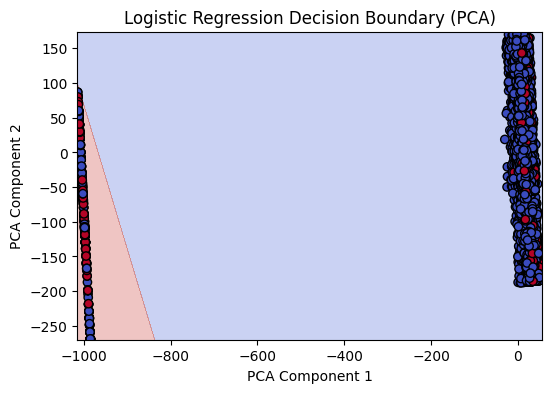

In [54]:
plt.figure(figsize=(6, 4))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolors='k')
plt.title("Logistic Regression Decision Boundary (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

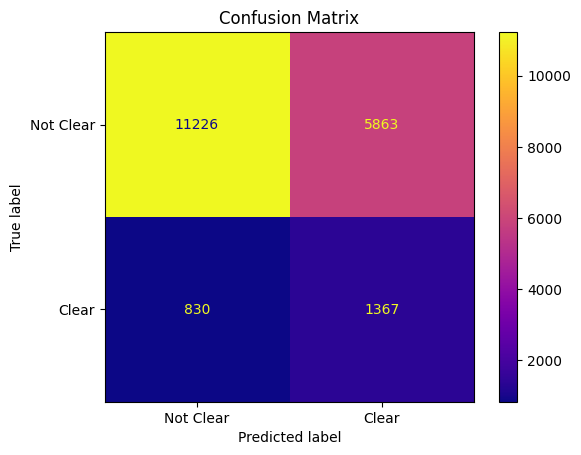

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Clear', 'Clear']
)

disp.plot(cmap=plt.cm.plasma)
plt.title("Confusion Matrix")
plt.show()